# 🎵 Spotify Machine Learning Project
---
### **Objective:** Applying classification and clustering algorithms to analyze music features and predict track patterns.

### **🚀 Implementation Steps:**
* **Algorithms:** KNN, K-Means, and Naive Bayes.
* **Task:** Multi-model analysis for classification and grouping.
* **Evaluation:** Performance check using Confusion Matrix and Regression metrics ($MSE, MAE, RMSE, R^2$).

**Prepared by:** Hala & Abdallah

#**Step 1: Data Loading & Library Setup**
In this initial step, we import the essential Python libraries for data manipulation and machine learning. We also load the Spotify 2023 dataset using the appropriate encoding to ensure all character data is correctly read.

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
# Make sure 'spotify-2023.csv' is uploaded to your Colab environment
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')


#**Step 2: Data Cleaning & Preprocessing**
In this step, we handle data inconsistencies by converting the 'streams' column to a numeric format and removing any invalid entries. We also address missing values in the 'key' and 'shazam charts' columns to ensure our dataset is complete and ready for analysis.

In [11]:
# 2. Data Cleaning
# Convert 'streams' to numeric, forcing errors to NaN then dropping them
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams'])
# Filling missing values in 'key' with 'Unknown' and 'in_shazam_charts' with 0
df['key'] = df['key'].fillna('Unknown')
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)



#**Step 3: Feature Selection (Audio Features)**
In this step, we isolate the specific numerical attributes that define the musical characteristics of each track. These features—such as BPM, danceability, and energy—will be the primary inputs for our machine learning models to identify patterns and similarities

In [12]:
# 3. Feature Selection (Audio Features)
features_list = [
    'bpm', 'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'
]
X = df[features_list]


#**Step 4: Feature Scaling**
Scaling is essential for distance-based algorithms like KNN and K-Means. By using StandardScaler, we transform our features to have a mean of 0 and a standard deviation of 1, ensuring that no single feature dominates the model due to its numerical range.

#**Step 5: Final Data Verification**
In this final step of the preprocessing phase, we verify the integrity of our cleaned and scaled dataset. This summary confirms that the data is properly formatted and ready to be fed into our Machine Learning models.

In [13]:
# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Summary Output
print("Dataset loaded successfully!")
print(f"Shape of features: {X_scaled.shape}")
print(df.info())

Dataset loaded successfully!
Shape of features: (952, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            952 non-null    object 
 1   artist(s)_name        952 non-null    object 
 2   artist_count          952 non-null    int64  
 3   released_year         952 non-null    int64  
 4   released_month        952 non-null    int64  
 5   released_day          952 non-null    int64  
 6   in_spotify_playlists  952 non-null    int64  
 7   in_spotify_charts     952 non-null    int64  
 8   streams               952 non-null    float64
 9   in_apple_playlists    952 non-null    int64  
 10  in_apple_charts       952 non-null    int64  
 11  in_deezer_playlists   952 non-null    object 
 12  in_deezer_charts      952 non-null    int64  
 13  in_shazam_charts      952 non-null    object 
 14  bpm                   

#**Step 6: Cleaning Platform Metrics & Categorical Exploration**
In this step, we fix the formatting of platform-specific metrics. Many values in 'Deezer' and 'Shazam' columns contain commas (e.g., "1,234"), which prevents them from being read as numbers. We remove these commas and convert the data to a numeric format to maintain data integrity.

In [20]:
# Convert 'in_deezer_playlists' to numeric, coercing errors
df['in_deezer_playlists'] = pd.to_numeric(df['in_deezer_playlists'], errors='coerce')

# Convert 'in_shazam_charts' to numeric, coercing errors
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors='coerce')

# Fill any NaNs created by coercion in 'in_deezer_playlists' or 'in_shazam_charts' with 0
df['in_deezer_playlists'] = df['in_deezer_playlists'].fillna(0)
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

print("Value counts for 'key' column:")
print(df['key'].value_counts())
print("\nValue counts for 'mode' column:")
print(df['mode'].value_counts())

Value counts for 'key' column:
key
C#         120
G           96
Unknown     95
G#          91
F           89
B           81
D           81
A           74
F#          73
E           62
A#          57
D#          33
Name: count, dtype: int64

Value counts for 'mode' column:
mode
Major    549
Minor    403
Name: count, dtype: int64


#**Step 7: Exploratory Data Analysis (Feature Distributions)**
In this step, we use visual tools to understand our data better. By plotting histograms with Kernel Density Estimates (KDE), we can see the distribution of each audio feature (like BPM and Energy). This help us identify patterns, skewness, and potential outliers before we start building our Machine Learning models.

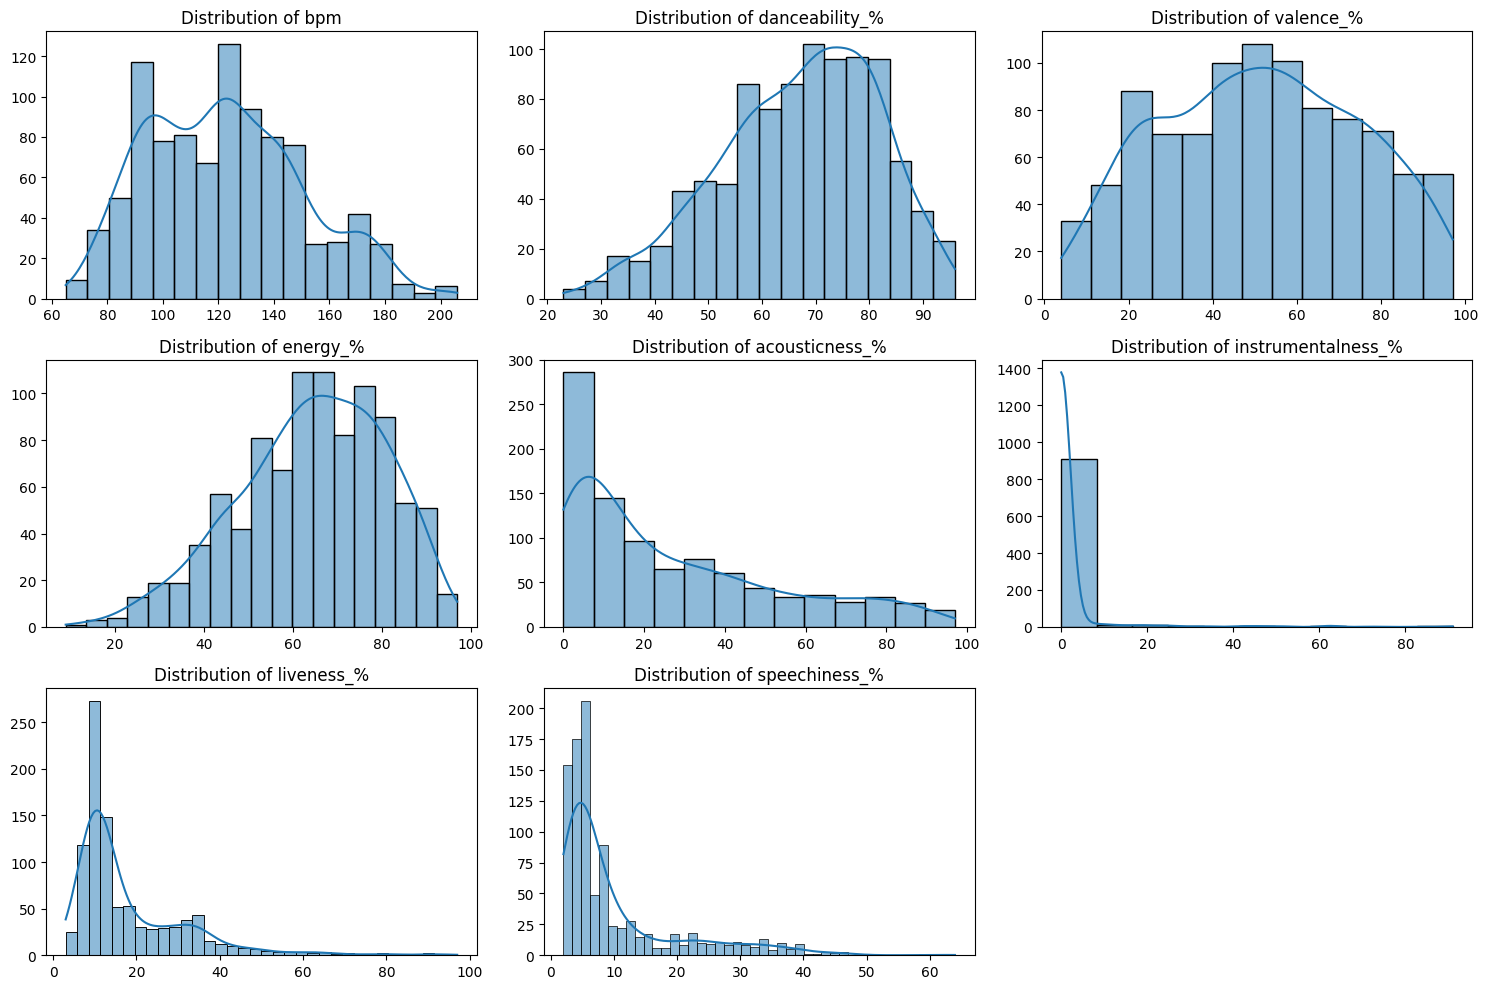

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_list):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    sns.histplot(df[feature], kde=True)  # Plot histogram with KDE
    plt.title(f'Distribution of {feature}')
    plt.xlabel('')  # Remove x-label to avoid clutter
    plt.ylabel('')  # Remove y-label to avoid clutter

plt.tight_layout()  # Adjust layout to prevent overlapping titles
plt.show()


#**Step 8: Regression Model Evaluation & Performance Metrics**
In this step, we evaluate the predictive power of our regression model using standard performance metrics. By calculating MAE, MSE, RMSE, and the R-squared score, we can quantify the accuracy of our predictions and determine how well our features explain the variation in the number of streams.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define target variable
y = df['streams']

# Split data into training and testing sets
# Assuming X_scaled is already defined from previous steps
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and train a Linear Regression model (baseline)
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Calculate R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): 378251615.1381
Mean Squared Error (MSE): 247341429244813312.0000
Root Mean Squared Error (RMSE): 497334323.4131
R-squared (R2 Score): -0.0104


#**Step 9: Visualizing Model Performance**
To better understand our regression results, we use visual diagnostics. The Scatter Plot compares the actual stream counts against our model's predictions to check for correlation, while the Residuals Histogram helps us analyze the distribution of errors. A normal distribution of residuals indicates that the model is performing consistently across the dataset.

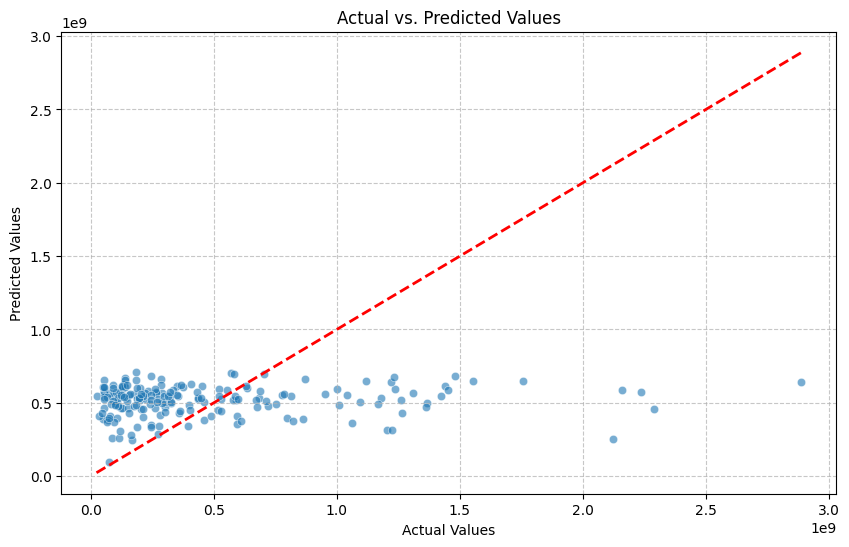

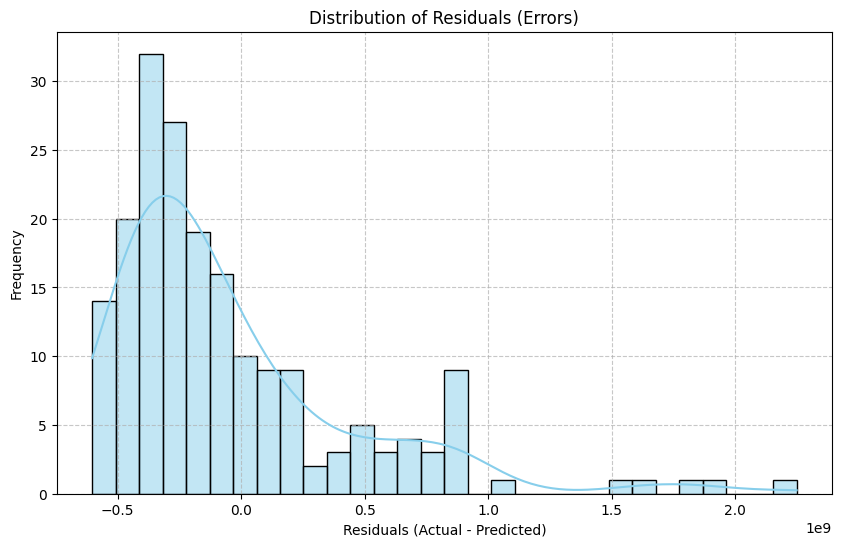

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot: Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal reference line
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Histogram of Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#**Step 10: K-Nearest Neighbors (KNN) Classification**
In this step, we transition from regression to classification using the KNN algorithm. Our goal is to classify tracks into their musical 'Mode' (Major or Minor) based on their audio features. We evaluate the model's accuracy and use a Confusion Matrix to visualize how well the algorithm distinguishes between the two categories.

KNN Accuracy Score: 0.5288

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.42      0.44        85
           1       0.57      0.61      0.59       106

    accuracy                           0.53       191
   macro avg       0.52      0.52      0.52       191
weighted avg       0.52      0.53      0.53       191



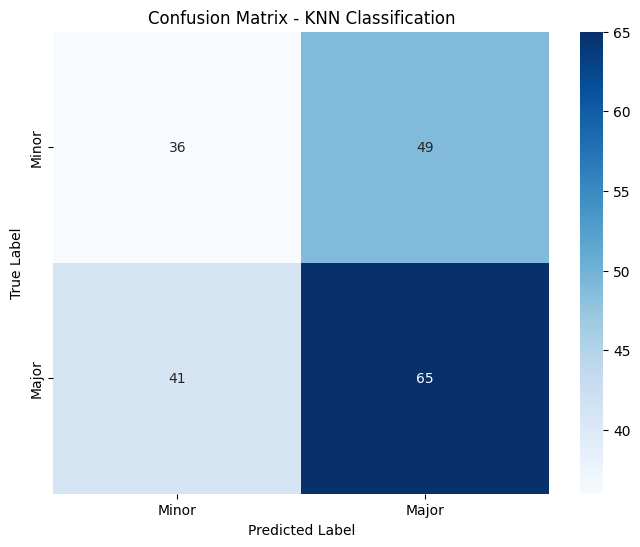

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the target variable (Encoding 'mode': Major=1, Minor=0)
y_class = df['mode'].map({'Major': 1, 'Minor': 0})

# 2. Split the data for classification
# We use X_scaled which we prepared in Step 4
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# 3. Initialize and train the KNN model
# We'll start with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_c, y_train_c)

# 4. Make predictions
y_pred_knn = knn.predict(X_test_c)

# 5. Evaluate the model
accuracy = accuracy_score(y_test_c, y_pred_knn)
print(f"KNN Accuracy Score: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_knn))

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Minor', 'Major'], yticklabels=['Minor', 'Major'])
plt.title('Confusion Matrix - KNN Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()